# v1 — метод затухания (gravity / distance-decay)

**Автор части:** Фёдор Кравченко

Вес ячейки — потенциал доступности к городам:

$$w_i = \sum_j m_j \cdot f(d_{ij}), \qquad m_j = (\mathrm{pop}_j / \max \mathrm{pop})^\beta,$$

где $d_{ij}$ — расстояние от центроида ячейки $i$ до города $j$, $m_j$ — «масса»
города (нормированное население в степени $\beta$), $f$ — ядро затухания. Затем
региональная отгрузка $X$ разносится пропорционально $w_i$.

Улучшения по сравнению с наивным `1/(d+1)`:
- **города из OSM** (`place=city|town` с населением) вместо 6–9 точек вручную;
  список кэшируется в `data/processed/cities_<region>.csv` (готовится Overpass-
  запросом в разделе 1);
- города **фильтруются по близости к региону** (`buffer_km=30`): города соседних
  регионов в углах bbox не тянут отгрузку в чужие места, но Москва (федеральный
  город в «дырке» области) сохраняется;
- **нелинейная масса** `pop^β`: β=1 — линейно, β>1 — концентрация в крупных
  городах (ср. эластичность регрессии v3 ≈ 2.77);
- сравниваются три ядра (exp/gauss/power); параметры (σ, β) подбираются по
  ранговой корреляции веса с растром населения WorldPop.

**Зависимости:** сетки с признаками `data/processed/grid_*_1km_features.gpkg`
(`02_grid.ipynb`). Код метода: `src/spatial_decay.py`.


In [1]:
import json
import os
import sys
import time
import urllib.request
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
os.environ.setdefault("PROJ_DATA", str(Path(sys.executable).parents[1] / "share" / "proj"))

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "..")
from src import spatial_decay as sd

ROOT = Path("..")
PROC = ROOT / "data" / "processed"
RESULTS = ROOT / "results"

REGIONS = {
    "moscow":    dict(file="grid_moscow_1km_features.gpkg",        title="Московская область", border="border_mo.gpkg"),
    "krasnodar": dict(file="grid_krasnodar_1km_features.gpkg",     title="Краснодарский край", border="border_krasnodar.gpkg"),
    "yakutia":   dict(file="grid_yakutia_center_1km_features.gpkg", title="Якутия (центр)",     border="border_ya_center.gpkg"),
}
print("Регионов:", list(REGIONS))


Регионов: ['moscow', 'krasnodar', 'yakutia']


## 1. Список городов из OSM (Overpass)

Тянем `place=city|town` с тегом `population` в bbox каждой сетки и кэшируем в
`data/processed/cities_<region>.csv`. Повторный запуск читает кэш (без сети).
Поставьте `FORCE_FETCH = True`, чтобы обновить.


In [2]:
FORCE_FETCH = False
OVERPASS = "https://overpass-api.de/api/interpreter"
HEADERS = {"User-Agent": "mipt-prak-spatial/1.0 (student project)"}

def fetch_cities(key):
    g = gpd.read_file(PROC / REGIONS[key]["file"]).to_crs(4326)
    s, w, n, e = (*g.total_bounds[[1, 0]], *g.total_bounds[[3, 2]])
    q = f'''[out:json][timeout:90];
(
  node["place"~"^(city|town)$"]["name"]({s},{w},{n},{e});
  way["place"~"^(city|town)$"]["name"]({s},{w},{n},{e});
  relation["place"~"^(city|town)$"]["name"]({s},{w},{n},{e});
);
out center tags;'''
    req = urllib.request.Request(OVERPASS, data=q.encode(), headers=HEADERS, method="POST")
    data = json.loads(urllib.request.urlopen(req, timeout=120).read())
    rows = []
    for el in data["elements"]:
        t = el.get("tags", {})
        if not t.get("name"):
            continue
        lat, lon = (el.get("lat"), el.get("lon")) if el["type"] == "node" else \
                   (el.get("center", {}).get("lat"), el.get("center", {}).get("lon"))
        if lat is None:
            continue
        pop = t.get("population")
        try:
            pop = int(str(pop).replace(" ", "").replace(",", "")) if pop else None
        except ValueError:
            pop = None
        rows.append({"name": t["name"], "lon": lon, "lat": lat, "population": pop, "place": t.get("place")})
    return pd.DataFrame(rows).drop_duplicates(subset=["name"]).reset_index(drop=True)

for key in REGIONS:
    path = PROC / f"cities_{key}.csv"
    if FORCE_FETCH or not path.exists():
        for attempt in range(3):
            try:
                fetch_cities(key).to_csv(path, index=False); break
            except Exception as exc:
                print(f"{key}: попытка {attempt+1}: {type(exc).__name__}"); time.sleep(8)
    df = pd.read_csv(path)
    print(f"{REGIONS[key]['title']:24s}  city/town={len(df):4d}  с населением={int(df['population'].notna().sum()):4d}")


Московская область        city/town= 219  с населением= 212
Краснодарский край        city/town= 131  с населением= 129
Якутия (центр)            city/town=   7  с населением=   7


## 2. Загрузка сеток и фильтрация городов

In [3]:
BUFFER_KM = sd.DEFAULT_BUFFER_KM  # 30 км

grids = {}
for key, cfg in REGIONS.items():
    g = gpd.read_file(PROC / cfg["file"])
    grids[key] = g
    n_all = len(sd.cities_gdf(key, g.crs))
    n_use = len(sd.cities_gdf(key, g.crs, grid=g, buffer_km=BUFFER_KM))
    print(f"{cfg['title']:24s}  ячеек={len(g):>7,}  городов: всего {n_all:>4} -> в работе {n_use:>4} (буфер {BUFFER_KM:g} км)")


Московская область        ячеек=141,967  городов: всего  212 -> в работе  177 (буфер 30 км)


Краснодарский край        ячеек=185,691  городов: всего  129 -> в работе  119 (буфер 30 км)


Якутия (центр)            ячеек=160,801  городов: всего    7 -> в работе    7 (буфер 30 км)


## 3. Подбор (σ, β) по корреляции с WorldPop

Для каждого ядра перебираем масштаб σ и степень массы β, считаем Spearman-
корреляцию веса с населением WorldPop. β>1 концентрирует массу в крупнейшем
городе — это повышает Джини, но обычно **снижает** корреляцию с распределённым
населением, поэтому по этому критерию выигрывает β≈1.


In [4]:
SIGMA_GRID = {
    "exp":   [3, 5, 8, 10, 15, 20, 30, 40, 60],
    "gauss": [3, 5, 8, 10, 15, 20, 30, 40, 60],
    "power": [1.0, 1.5, 2.0, 2.5, 3.0, 4.0],
}
BETAS = [1.0, 1.5, 2.0, 2.77]

rows = []
for key, g in grids.items():
    Xr = sd.X_SHIPPING[key]
    for kind in sd.KERNELS:
        (bs, bb, rho), _ = sd.tune_gravity(g, key, kind, SIGMA_GRID[kind], BETAS, buffer_km=BUFFER_KM)
        v = sd.distribute_decay(g, Xr, key, bs, kind, beta=bb, buffer_km=BUFFER_KM)
        rows.append({
            "Регион": REGIONS[key]["title"], "region_key": key, "Ядро": kind,
            "sigma": bs, "beta": bb, "Spearman(WorldPop)": round(rho, 3),
            "Джини": round(sd.gini(v), 3), "Top-10%": round(sd.top_share(v), 3),
        })
kernels_df = pd.DataFrame(rows)
kernels_df


,Регион,region_key,Ядро,sigma,beta,Spearman(WorldPop),Джини,Top-10%
0,Московская область,moscow,exp,10.0,1.00,0.455,0.787,0.694
1,Московская область,moscow,gauss,10.0,1.00,0.442,0.793,0.660
2,Московская область,moscow,power,2.5,1.00,0.495,0.757,0.680
3,Краснодарский край,krasnodar,exp,3.0,1.00,0.250,0.927,0.889
4,Краснодарский край,krasnodar,gauss,5.0,1.00,0.247,0.931,0.893
5,Краснодарский край,krasnodar,power,4.0,1.00,0.250,0.983,0.983
6,Якутия (центр),yakutia,exp,5.0,1.00,0.163,0.988,0.997
7,Якутия (центр),yakutia,gauss,3.0,2.77,0.164,0.999,1.000
8,Якутия (центр),yakutia,power,4.0,1.00,0.158,0.998,0.999


## 4. Расчёт v1

Используем **экспоненциальное** ядро во всех регионах (стандарт gravity-моделей,
по корреляции с WorldPop — лучшее или в пределах шума). σ и β — лучшие из перебора
по exp. Для справки считаем также вариант с β=2.77 (эластичность регрессии v3):
он сильнее концентрирует отгрузку, но хуже коррелирует с населением.


In [5]:
CHOSEN_KERNEL = "exp"

chosen = {}
metrics_rows = []
for key, g in grids.items():
    cfg, Xr = REGIONS[key], sd.X_SHIPPING[key]
    (sigma, beta, rho), _ = sd.tune_gravity(g, key, CHOSEN_KERNEL, SIGMA_GRID[CHOSEN_KERNEL], BETAS, buffer_km=BUFFER_KM)

    v1 = sd.distribute_decay(g, Xr, key, sigma, CHOSEN_KERNEL, beta=beta, buffer_km=BUFFER_KM)
    g["method_otgr_v1"] = v1
    chosen[key] = (CHOSEN_KERNEL, sigma, beta)

    # вариант с эластичностью регрессии v3 (β=2.77), тот же σ
    g["method_otgr_v1_b277"] = sd.distribute_decay(g, Xr, key, sigma, CHOSEN_KERNEL, beta=2.77, buffer_km=BUFFER_KM)

    # прежний наивный вариант: ближайший город, 1/(d+1), без населения и фильтра
    d_min = sd.city_distances_km(g, sd.cities_gdf(key, g.crs)).min(axis=1)
    w_old = 1.0 / (d_min + 1.0)
    v_old = Xr * w_old / w_old.sum()
    g["method_otgr_v1_old"] = v_old

    metrics_rows.append({
        "Регион": cfg["title"], "region_key": key,
        "Ядро": CHOSEN_KERNEL, "sigma": sigma, "beta": beta,
        "Городов": len(sd.cities_gdf(key, g.crs, grid=g, buffer_km=BUFFER_KM)),
        "Spearman(WorldPop)": round(rho, 3),
        "Джини старый 1/(d+1)": round(sd.gini(v_old), 3),
        "Top-10% старый": round(sd.top_share(v_old), 3),
        "Джини v1": round(sd.gini(v1), 3),
        "Top-10% v1": round(sd.top_share(v1), 3),
        "Джини v1 β=2.77": round(sd.gini(g["method_otgr_v1_b277"]), 3),
    })

metrics_df = pd.DataFrame(metrics_rows)
print("Выбрано (kind, sigma, beta):", chosen)
metrics_df


Выбрано (kind, sigma, beta): {'moscow': ('exp', 10.0, 1.0), 'krasnodar': ('exp', 3.0, 1.0), 'yakutia': ('exp', 5.0, 1.0)}


,Регион,region_key,Ядро,sigma,beta,Городов,Spearman(WorldPop),Джини старый 1/(d+1),Top-10% старый,Джини v1,Top-10% v1,Джини v1 β=2.77
0,Московская область,moscow,exp,10.0,1.0,177,0.455,0.408,0.323,0.787,0.694,0.961
1,Краснодарский край,krasnodar,exp,3.0,1.0,119,0.250,0.380,0.309,0.927,0.889,0.997
2,Якутия (центр),yakutia,exp,5.0,1.0,7,0.163,0.430,0.356,0.988,0.997,0.994


## 5. Карты: старое `1/(d+1)` vs гравитация (β из перебора)

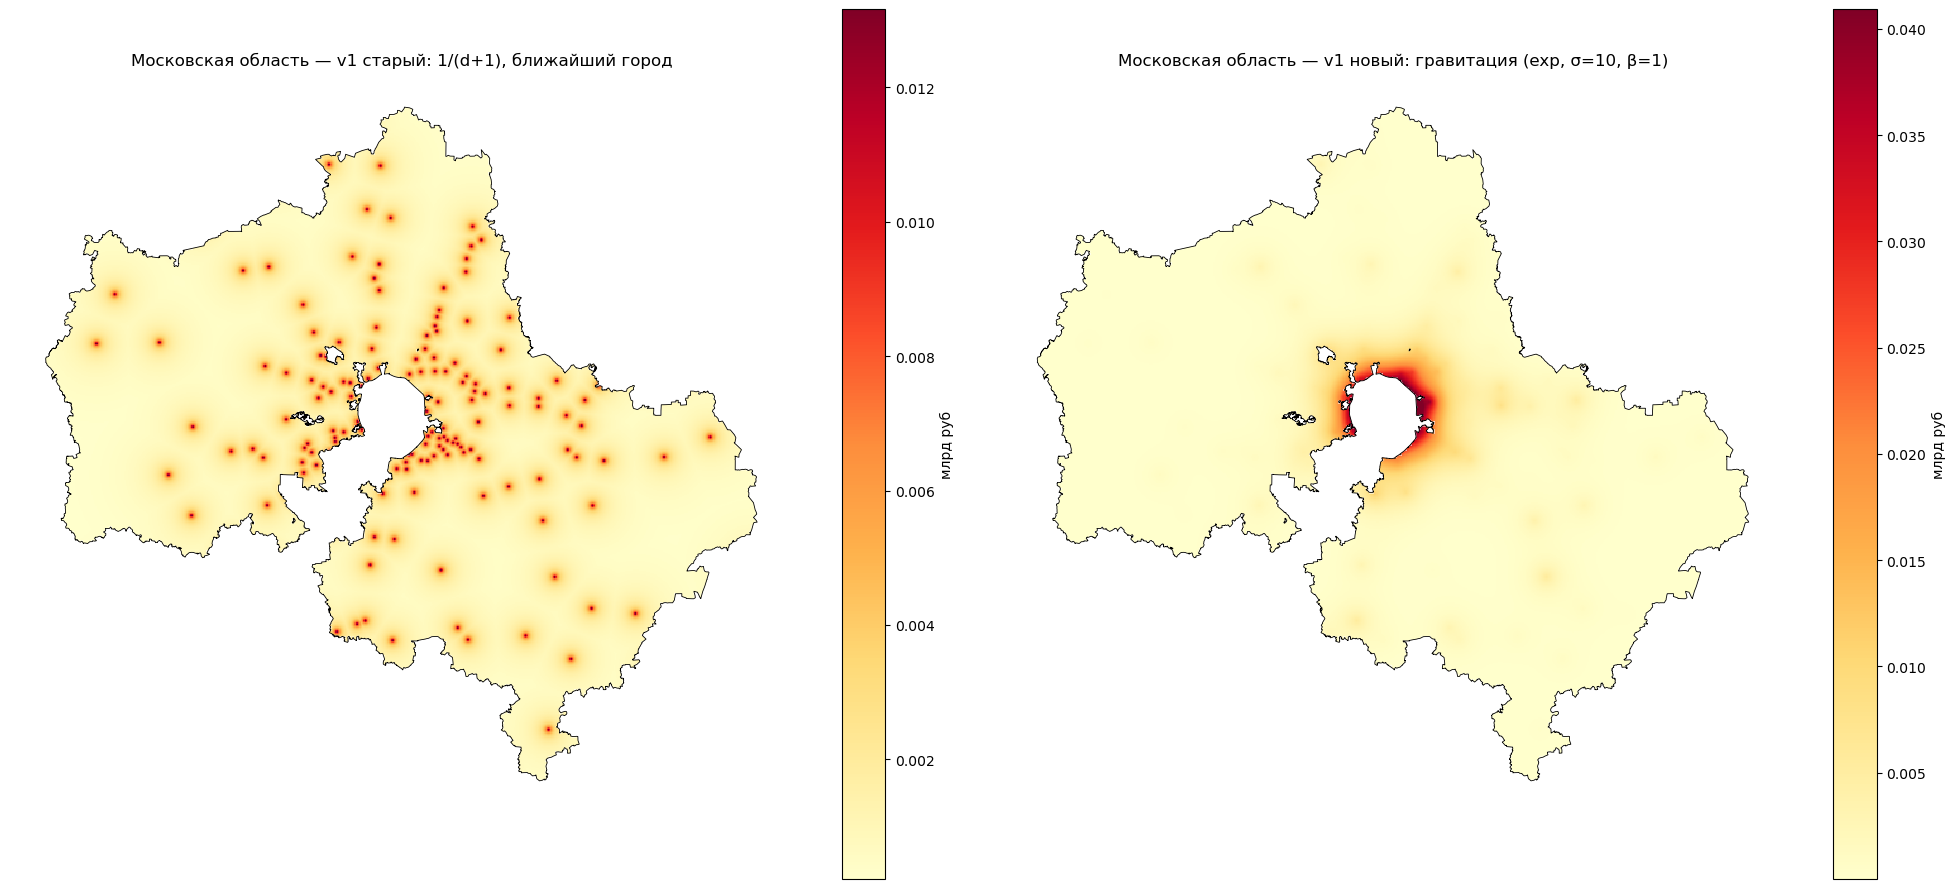

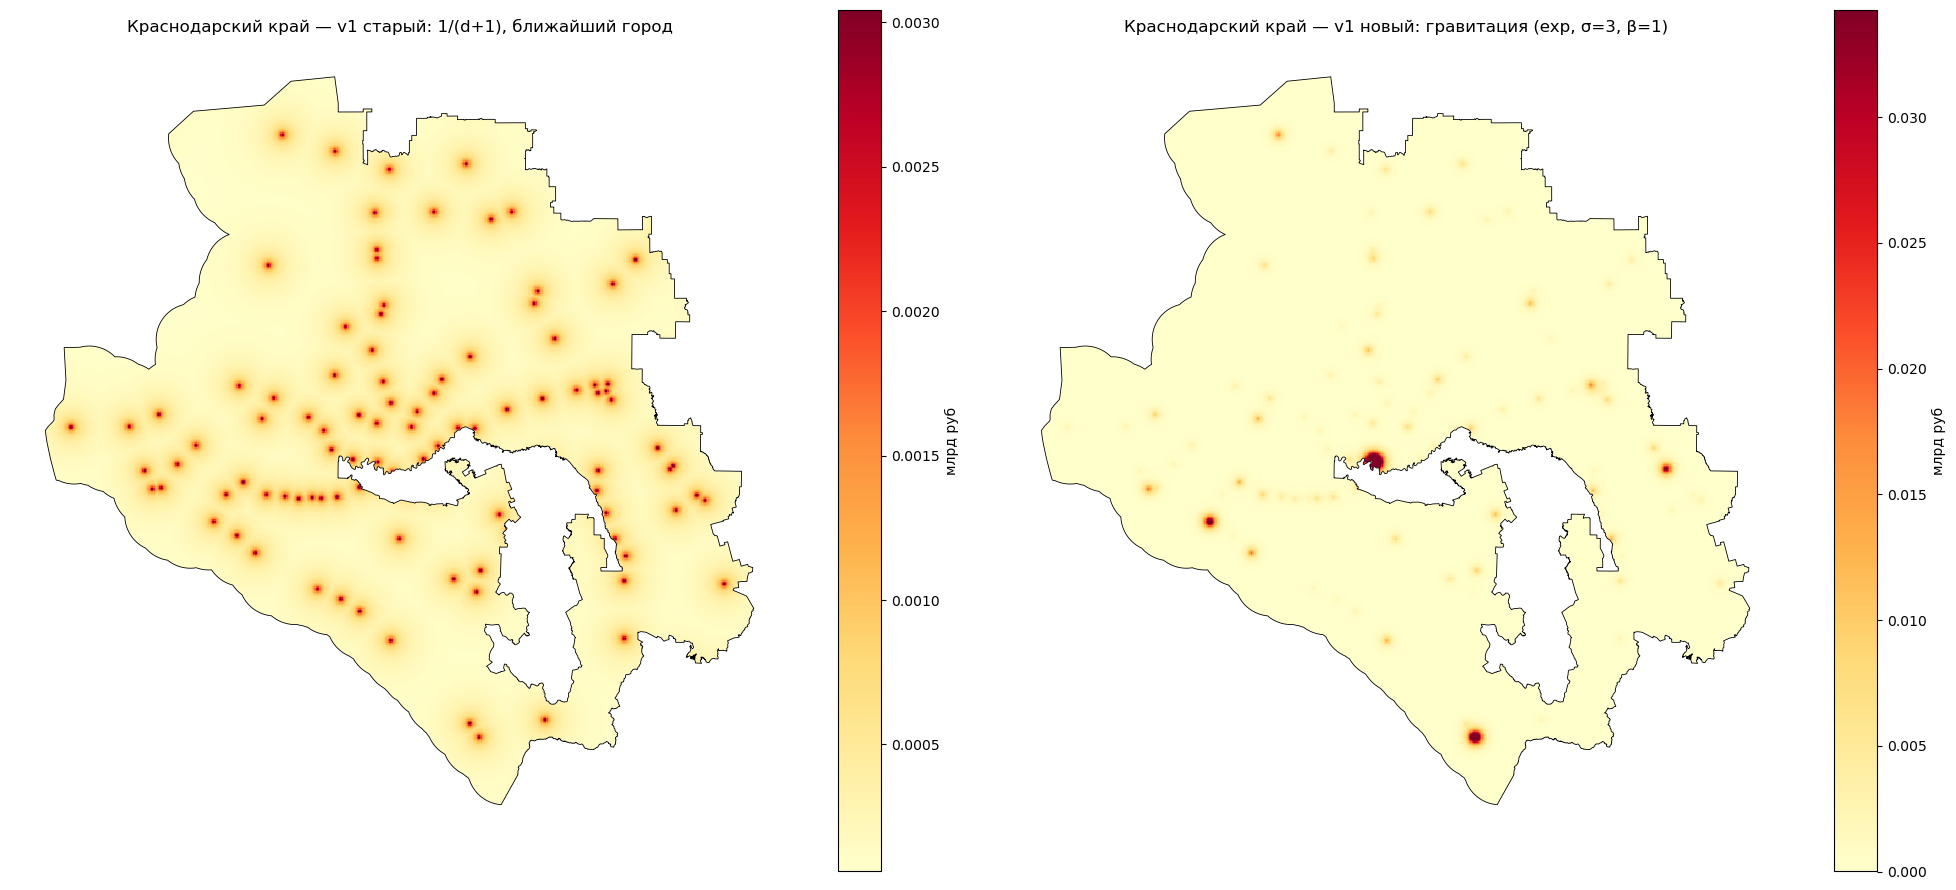

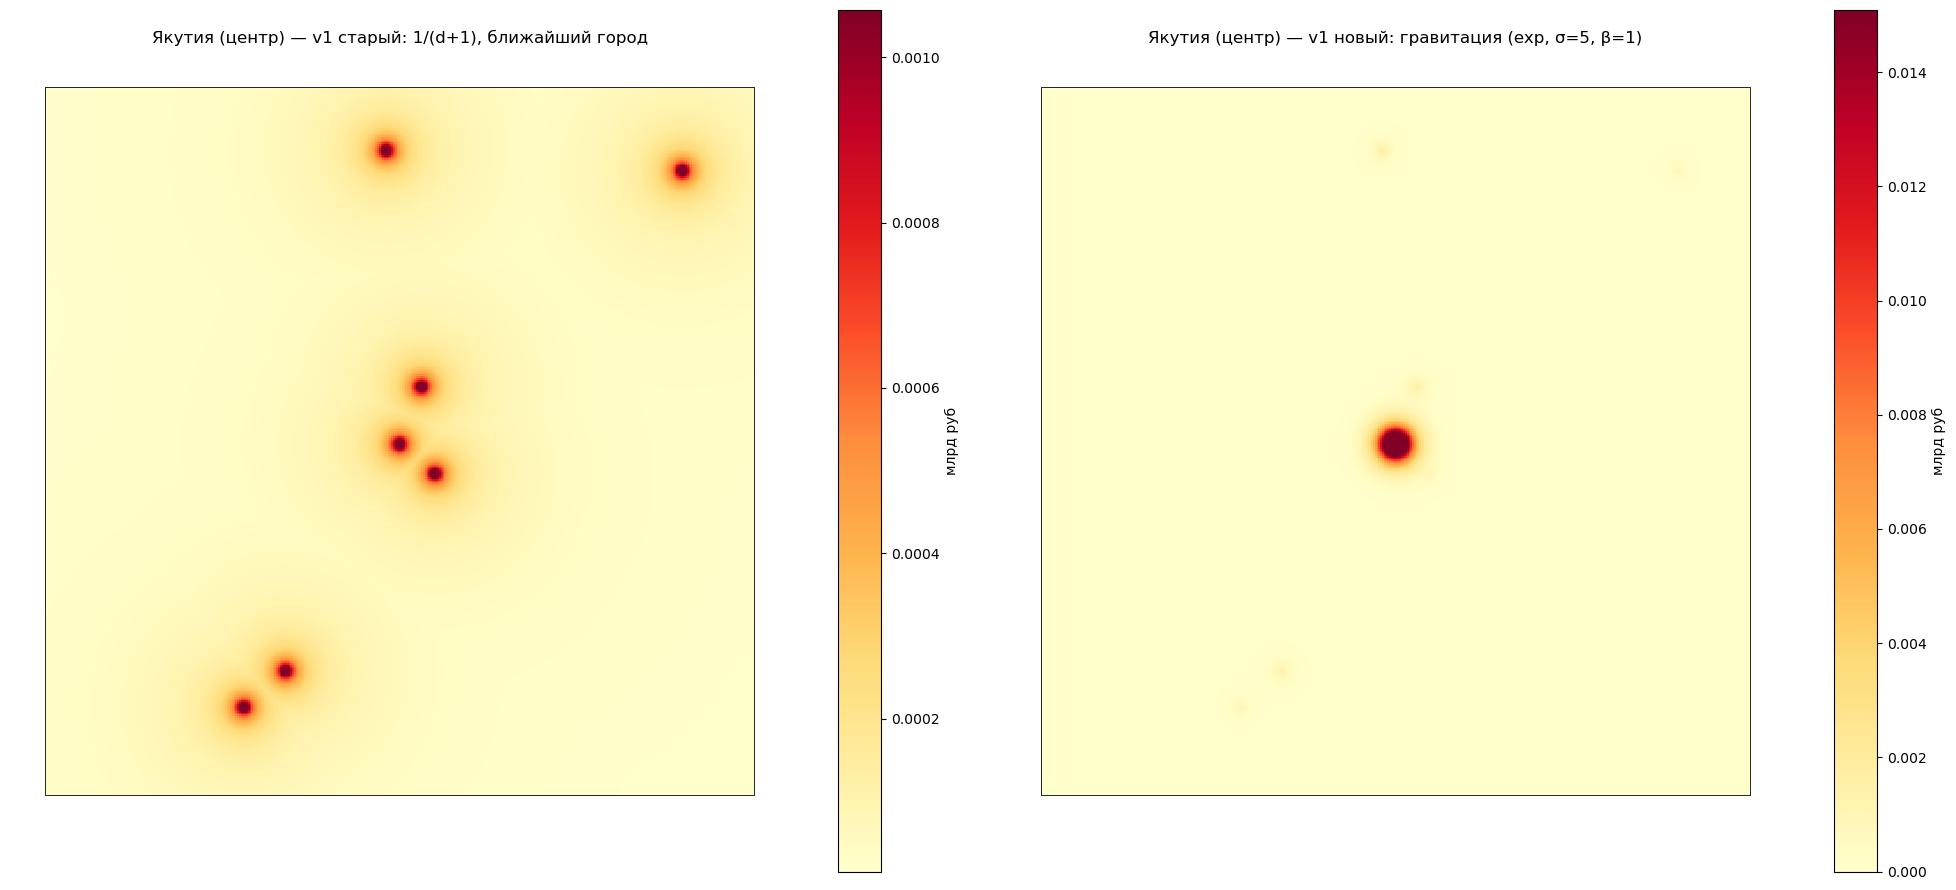

In [6]:
def plot_compare(key):
    g, cfg = grids[key], REGIONS[key]
    border = gpd.read_file(PROC / cfg["border"]).to_crs(g.crs)
    _, sigma, beta = chosen[key]
    fig, axes = plt.subplots(1, 2, figsize=(20, 9))
    for ax, col, title in [
        (axes[0], "method_otgr_v1_old", "v1 старый: 1/(d+1), ближайший город"),
        (axes[1], "method_otgr_v1",     f"v1 новый: гравитация (exp, σ={sigma:g}, β={beta:g})"),
    ]:
        g.plot(column=col, ax=ax, cmap="YlOrRd", legend=True,
               legend_kwds={"label": "млрд руб"}, vmax=g[col].quantile(0.999), linewidth=0)
        border.boundary.plot(ax=ax, color="black", linewidth=0.6)
        ax.set_title(f"{cfg['title']} — {title}"); ax.set_axis_off()
    fig.tight_layout()
    fig.savefig(RESULTS / f"decay_{key}.png", dpi=110, bbox_inches="tight")
    plt.show()

for key in REGIONS:
    plot_compare(key)


### Форма ядер затухания

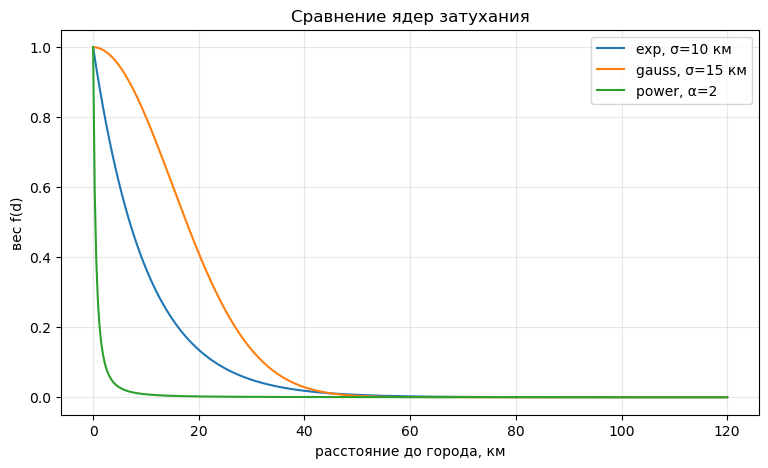

In [7]:
d = np.linspace(0, 120, 400)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(d, sd.decay_kernel(d, 10, "exp"),   label="exp, σ=10 км")
ax.plot(d, sd.decay_kernel(d, 15, "gauss"), label="gauss, σ=15 км")
ax.plot(d, sd.decay_kernel(d, 2.0, "power"), label="power, α=2")
ax.set_xlabel("расстояние до города, км"); ax.set_ylabel("вес f(d)")
ax.set_title("Сравнение ядер затухания"); ax.legend(); ax.grid(alpha=0.3)
fig.savefig(RESULTS / "decay_kernels_shape.png", dpi=110, bbox_inches="tight")
plt.show()


## 6. Вариант v1-net: затухание по времени в пути (дорожная сеть)

Вместо евклидова расстояния используем **время в пути по магистральной сети**
(OSM `motorway|trunk|primary|secondary`, скорости → `travel_time`). Расстояние
ячейка→город = время по сети между ближайшими узлами + «подъезд» по прямой
(25 км/ч) от ячейки и города до своих узлов. Это учитывает, что хозяйственная
активность тянется вдоль трасс, а не идеальными кругами (реки, объезды и т.п.).

Граф магистралей кэшируется в `data/processed/graphs/roads_<region>.graphml`
(скачивание через Overpass — медленное, повторный запуск читает кэш). σ теперь в
минутах; подбирается так же — по корреляции с WorldPop. Если граф региона
недоступен, регион пропускается.


In [8]:
SIGMA_MIN = [5, 10, 15, 20, 30, 45, 60, 90]

net_rows = []
net_min_cache = {}
for key, g in grids.items():
    cfg, Xr = REGIONS[key], sd.X_SHIPPING[key]
    graph_path = sd.GRAPH_DIR / f"roads_{key}.graphml"
    if not graph_path.exists():
        print(f"{cfg['title']}: граф не закэширован — пропуск (скачайте: sd.load_road_graph('{key}'))")
        continue
    G = sd.load_road_graph(key)  # из кэша graphml

    cities = sd.cities_gdf(key, g.crs, grid=g, buffer_km=BUFFER_KM)
    net = sd.network_minutes(g, cities, G)
    net_min_cache[key] = (net, cities)
    reach = np.isfinite(net.min(axis=1)).mean()

    (smin, beta, rho), _ = sd.tune_on_matrix(net, cities["population"].to_numpy(),
                                             g["population"].to_numpy(), "exp", SIGMA_MIN, BETAS)
    vnet = sd.distribute_decay_network(g, Xr, cities, net, smin, "exp", beta)
    g["method_otgr_v1net"] = vnet

    _, e_sigma, e_beta = chosen[key]
    net_rows.append({
        "Регион": cfg["title"], "region_key": key,
        "Достижимо": round(float(reach), 3),
        "σ_сеть, мин": smin, "β_сеть": beta, "Spearman сеть": round(rho, 3),
        "Джини euc": round(sd.gini(g["method_otgr_v1"]), 3),
        "Джини net": round(sd.gini(vnet), 3),
        "Top-10% net": round(sd.top_share(vnet), 3),
    })

net_df = pd.DataFrame(net_rows)
net_df


Краснодарский край: граф не закэширован — пропуск (скачайте: sd.load_road_graph('krasnodar'))
Якутия (центр): граф не закэширован — пропуск (скачайте: sd.load_road_graph('yakutia'))


,Регион,region_key,Достижимо,"σ_сеть, мин",β_сеть,Spearman сеть,Джини euc,Джини net,Top-10% net
0,Московская область,moscow,1.0,10.0,1.0,0.483,0.787,0.803,0.661


### Карты: гравитация по евклиду vs по дорожной сети

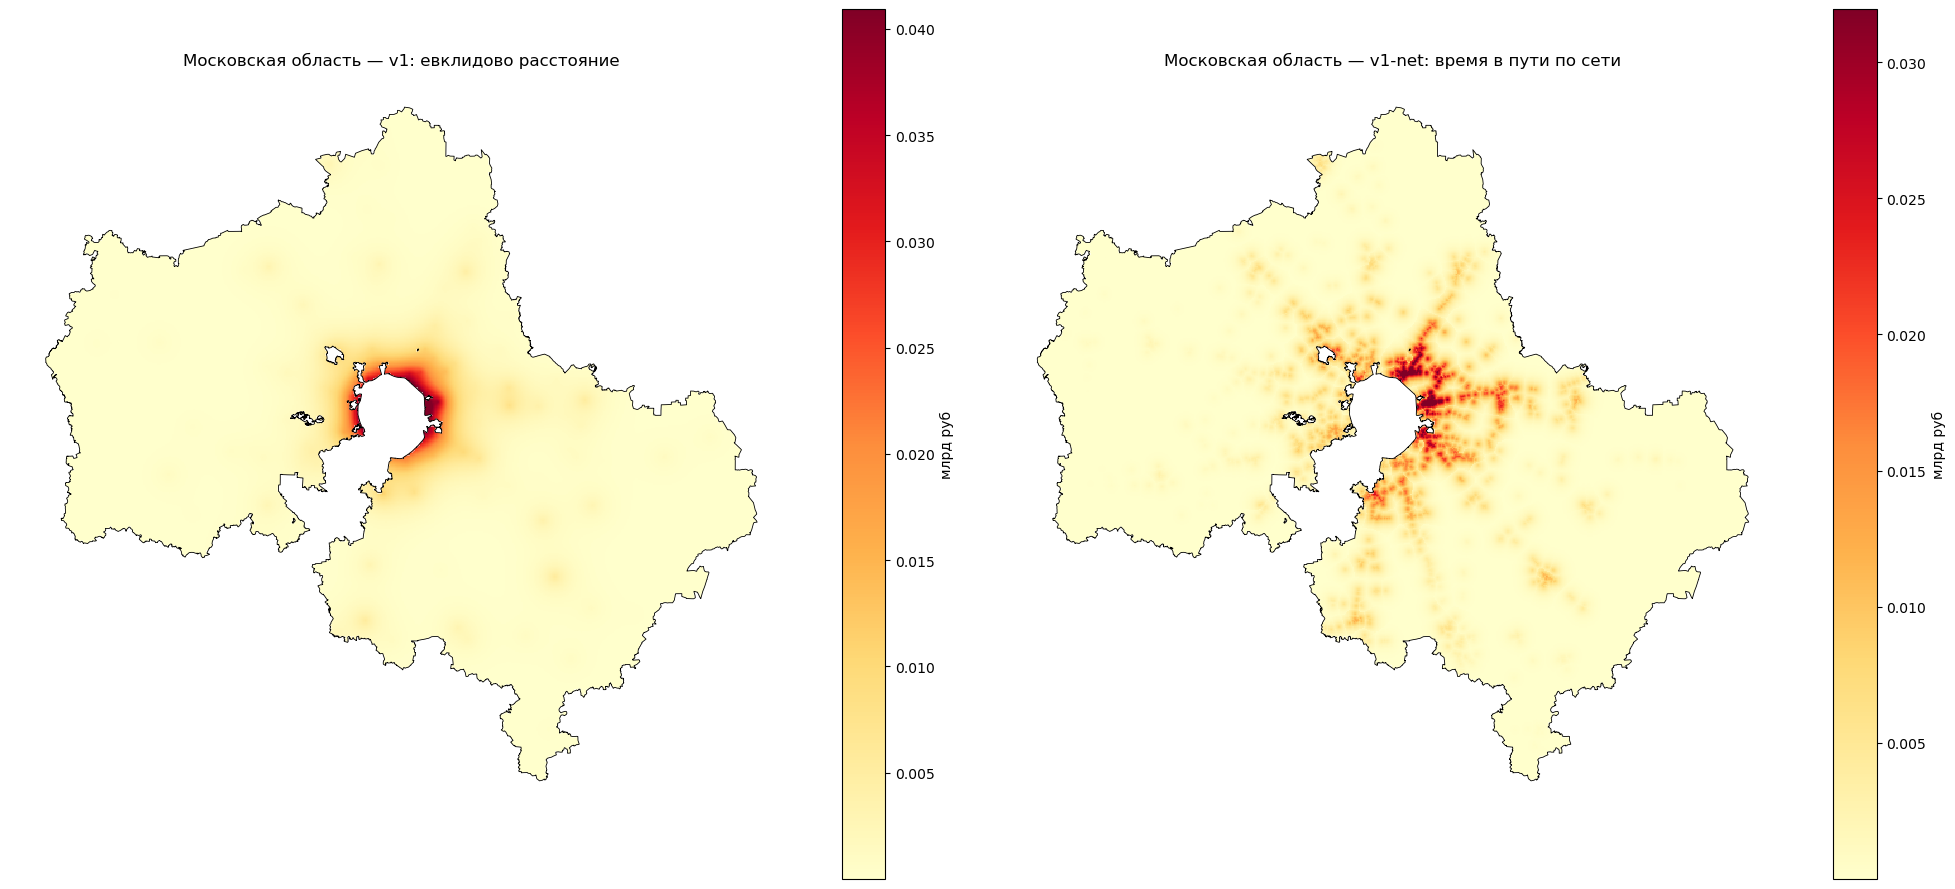

In [9]:
def plot_net(key):
    g, cfg = grids[key], REGIONS[key]
    if "method_otgr_v1net" not in g.columns:
        return
    border = gpd.read_file(PROC / cfg["border"]).to_crs(g.crs)
    fig, axes = plt.subplots(1, 2, figsize=(20, 9))
    for ax, col, title in [
        (axes[0], "method_otgr_v1",    "v1: евклидово расстояние"),
        (axes[1], "method_otgr_v1net", "v1-net: время в пути по сети"),
    ]:
        g.plot(column=col, ax=ax, cmap="YlOrRd", legend=True,
               legend_kwds={"label": "млрд руб"}, vmax=g[col].quantile(0.999), linewidth=0)
        border.boundary.plot(ax=ax, color="black", linewidth=0.6)
        ax.set_title(f"{cfg['title']} — {title}"); ax.set_axis_off()
    fig.tight_layout()
    fig.savefig(RESULTS / f"decay_net_{key}.png", dpi=110, bbox_inches="tight")
    plt.show()

for key in grids:
    plot_net(key)


## 7. Сохранение артефактов

- `results/decay_kernels.csv` — перебор (ядро × σ × β) по регионам;
- `results/decay_metrics.csv` — выбранный v1 (евклид), сравнение со старым `1/(d+1)` и β=2.77;
- `results/decay_net_metrics.csv` — сравнение евклид vs дорожная сеть;
- `results/decay_grids/grid_*_v1.gpkg` — сетки с колонками `method_otgr_v1` и (где есть) `method_otgr_v1net`.


In [10]:
kernels_df.drop(columns=["region_key"]).to_csv(RESULTS / "decay_kernels.csv", index=False)
metrics_df.drop(columns=["region_key"]).to_csv(RESULTS / "decay_metrics.csv", index=False)
if len(net_df):
    net_df.drop(columns=["region_key"]).to_csv(RESULTS / "decay_net_metrics.csv", index=False)

out_dir = RESULTS / "decay_grids"
out_dir.mkdir(exist_ok=True)
for key, g in grids.items():
    cols = ["cell_id", "geometry", "population", "method_otgr_v1"]
    if "method_otgr_v1net" in g.columns:
        cols.append("method_otgr_v1net")
    g[cols].to_file(out_dir / f"grid_{key}_v1.gpkg", driver="GPKG")

print("Сохранено в", RESULTS)
print(metrics_df[["Регион", "Городов", "sigma", "beta", "Джини v1", "Top-10% v1"]].to_string(index=False))
if len(net_df):
    print(); print(net_df[["Регион", "σ_сеть, мин", "Джини euc", "Джини net", "Spearman сеть"]].to_string(index=False))


Сохранено в ../results
            Регион  Городов  sigma  beta  Джини v1  Top-10% v1
Московская область      177   10.0   1.0     0.787       0.694
Краснодарский край      119    3.0   1.0     0.927       0.889
    Якутия (центр)        7    5.0   1.0     0.988       0.997

            Регион  σ_сеть, мин  Джини euc  Джини net  Spearman сеть
Московская область         10.0      0.787      0.803          0.483
